Next steps:

Does the angles thing eventually change over time?


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import scipy.stats

import util
from plot_setup import *

CMAP = "flare"

# STEPS = 20000
EXAMPLE_COSTS = [1.5, 3.0, 65.0]
STEPS = 5000

FOLDER = "/Users/brendan/Projects/trails/data/"

datafiles = [
    "cost-angles|2025-11-10/data.json", # just added this
    "cost-angles|2025-11-07/data.json",
    "cost-angles|2025-08-01/data.json",
    "cost-angles|2025-08-02/data.json",
]

In [2]:
# this is all the regular data
dfs = [
    util.load_data(FOLDER + datafile) for datafile in datafiles
]
df = pd.concat(dfs)
util.describe(df)

# this has the path plots
single_df = util.load_data(FOLDER + "cost-angles-single|2025-11-12/data.json")
# util.describe(single_df)

ratios: [100.0]
patch recovery: [0.001]
max costs: [1.25 1.5 2.0 3.0 5.0 9.0 17.0 33.0 65.0]
boundary conditions: ['SOLID']
num locations: [15 10 20]
random walker seeds: 4
random locations seeds: 2
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
settings.scenario : ['RANDOM_FIXED']
settings.X : [100]
steps: 20000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')


In [3]:
"""
Computes percentiles for all the max costs.
"""

MAX_COSTS = df["settings.maxCost"].unique()
PERCENTILES = [0.9, 0.95, 0.99]

def find_percentile(percentile, _headings):
    """
    Computes `percentile`th percentile of angle.
    """
    _headings = sorted(_headings, key=lambda h: h[0])
    total_weight = sum([h[1] for h in _headings])
    weights = [h[1] / total_weight for h in _headings]
    i = 0
    for cw in np.cumsum(weights):
        if cw >= percentile:
            return _headings[i][0] / np.pi * 180
        i += 1


cost_angles = {cost: {} for cost in MAX_COSTS}
for cost in MAX_COSTS:
    _df = df[
        (df["steps"] == STEPS) &
        (df["settings.maxCost"] == cost)
        # (df["settings.numLocations"] == 20)
    ]
    critical_angle = np.arccos(1 / cost) / np.pi * 180
    cost_angles[cost]["critical"] = critical_angle
    for percentile in PERCENTILES:
        cost_angles[cost][percentile] = find_percentile(percentile, _df["weightedHeadings"].explode())

In [4]:
def draw_a_b(subfig):

    LENGTH = 4
    #fig, 
    axs = subfig.subplots(2,
                            len(EXAMPLE_COSTS),
                            # figsize=(len(EXAMPLE_COSTS)*LENGTH, LENGTH * 2),
                            # figsize=(one_column_width, 50 / mm_to_inch),
                            # dpi=DPI
                         )
    # plt.subplots_adjust(wspace=0.5, hspace=0.2)
    for i, cost in enumerate(EXAMPLE_COSTS):
        row = single_df[(single_df["settings.maxCost"] == cost) & (single_df["steps"] == STEPS)].iloc[0]
    
        axs[0][i].imshow(np.reshape(row["patches"], (100, 100)), cmap="RdPu")
        axs[0][i].axis('off')
        
        for path in row.paths:
            axs[1][i].plot([p[0] for p in path], [(100 - p[1]) for p in path], c=COLORS[i])
            axs[1][i].axis(False)
            axs[1][i].set_xlim(0, 100)
            axs[1][i].set_ylim(0, 100)
        # plt.show()
    # fig.savefig("figures/4a_b.svg", dpi=DPI)

In [5]:
def draw_c(subfig):

    #fig,
    ax = subfig.subplots(
        # figsize=(88/mm_to_inch, 60/mm_to_inch)
    )

    # add_letter(subfig, 0.18, 0.9, "c")

    
    # maxCosts = [1.25, 1.5, 2.0, 3.0, 5.0, 9.0, 17.0, 33.0, 65.0]
    for i, cost in enumerate(EXAMPLE_COSTS):
        _df = df[(df["steps"] == STEPS) & (df["settings.maxCost"] == cost)]
        headings = _df["weightedHeadings"].explode()
    
        # print(cost_angles[cost]["critical"], cost_angles[cost][0.9])
    
    
        
        if i == 0:
            plt.axvline(x=cost_angles[cost]["critical"], ymin=0, ymax=(0.8 - i*0.1), linestyle='--', c=COLORS[i], label="critical angle")
        else:
            plt.axvline(x=cost_angles[cost]["critical"], ymin=0, ymax=(0.8 - i*0.1), linestyle='--', c=COLORS[i])
    
        # plt.axvline(x=cost_angles[cost][0.90], ymin=0, ymax=1, linestyle='-', c=COLORS[i], label=f"90th %")
    
    
        _weights = [h[1] for h in headings]
        weight_sum = sum(_weights)
        weights = [w / weight_sum for w in _weights]
        angles = [h[0] * 180 / np.pi for h in headings]
    
    
        p = sns.histplot(
            ax=ax,
            x=angles,
            weights=weights,
            bins=30,
            kde=True,
            binrange=(0.0, 180.0),
            log=True,
            alpha=0.25,
            color=COLORS[i],
            # label=f"cost: 1 + {cost - 1}"
        )
    
        
        
    
        # plt.xlim(0, 0.8)
        # plt.axis(False)
    ax.set_xlabel("Angle (degrees)", fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.set_ylim(10e-4, 10e-1)
    ax.legend(fontsize=9)
# fig.savefig("figures/4c.svg", dpi=DPI)
# fig.savefig("figures/4c.pdf", dpi=DPI)

# for i, cost in enumerate(EXAMPLE_COSTS):
#     plt.scatter([cost_angles[cost][0.9]], [0.1], color=COLORS[i], s=200, alpha=1)

In [6]:
def draw_d(subfig):
    # fig, 
    ax = subfig.subplots(
        #figsize=(88/mm_to_inch, 60/mm_to_inch)
    )
    
    # add_letter(subfig, 0.18, 0.9, "d")


    for p in [0.90]:
        sns.lineplot(
            ax=ax,
            y=[cost_angles[cost][p] for cost in MAX_COSTS],
            x=[cost_angles[cost]["critical"] for cost in MAX_COSTS],
            marker="o", c=COLORS[0],
            )
        ax.set_xlabel("Critical Angle (Degrees)", fontsize=9)
        ax.set_ylabel(f"{int(p*100)}th % Angle (Degrees)", fontsize=9)
    
        # draws a 1:1 straight line:
        # sns.lineplot(x=np.linspace(40, 100), y=np.linspace(40, 100))
    
        for i, cost in enumerate(EXAMPLE_COSTS):
            sns.scatterplot(
                ax=ax,
                x=[cost_angles[cost]["critical"]],
                y=[cost_angles[cost][p]],
                color=COLORS[i],
                s=200, alpha=1,
                marker="$\circ$",
                zorder=10)
    
    # fig.savefig("figures/4d.svg", dpi=DPI)
    # fig.savefig("figures/4d.pdf", dpi=DPI)

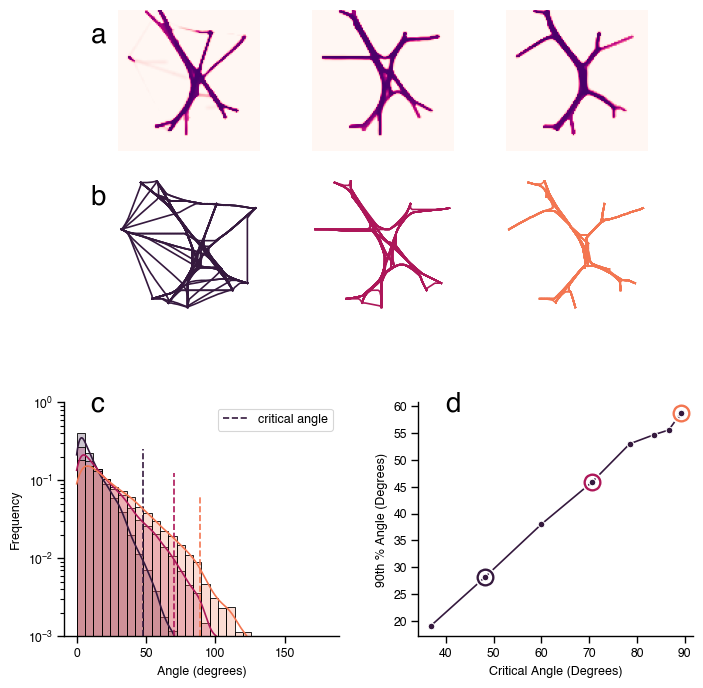

In [7]:
fig = plt.figure(figsize=(two_column_width, 180/mm_to_inch))
topfig, bottomfig = fig.subfigures(2, 1, height_ratios=(4, 3))

bottom_left, bottom_right = bottomfig.subfigures(1, 2)


add_letter(topfig, 0.1, .8, "a")
add_letter(topfig, 0.1, 0.4, "b")
add_letter(bottom_left, 0.2, .85, "c")
add_letter(bottom_right, 0.2, .85, "d")

draw_a_b(topfig)
draw_c(bottom_left)
draw_d(bottom_right)

fig.savefig("figures/4.svg")
fig.savefig("figures/4.pdf")